In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("Dataset_Day3.csv")

df["distance"] = np.sqrt(
    (df["dropoff_longitude"] - df["pickup_longitude"])**2 + (df["dropoff_latitude"] - df["pickup_latitude"])**2
)

print(df.head())

        key  fare_amount          pickup_datetime  pickup_longitude  \
0  24238194          7.5  2015-05-07 19:52:06 UTC        -73.999817   
1  27835199          7.7  2009-07-17 20:04:56 UTC        -73.994355   
2  44984355         12.9  2009-08-24 21:45:00 UTC        -74.005043   
3  25894730          5.3  2009-06-26 08:22:21 UTC        -73.976124   
4  17610152         16.0  2014-08-28 17:47:00 UTC        -73.925023   

   pickup_latitude  dropoff_longitude  dropoff_latitude  passenger_count  \
0        40.738354         -73.999512         40.723217                1   
1        40.728225         -73.994710         40.750325                1   
2        40.740770         -73.962565         40.772647                1   
3        40.790844         -73.965316         40.803349                3   
4        40.744085         -73.973082         40.761247                5   

   distance  
0  0.015140  
1  0.022103  
2  0.053109  
3  0.016528  
4  0.051031  


In [6]:
# Function to get outliers
def get_outliers(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    return df[
        (df[col] < (Q1 - 1.5 * IQR)) |
        (df[col] > (Q3 + 1.5 * IQR))
    ].index


# Combine outliers from all columns
outliers = get_outliers(df, 'fare_amount').union(
    get_outliers(df, 'passenger_count')
).union(
    get_outliers(df, 'distance')
)

print("Keys of rows with outliers:")

print(df.loc[outliers, 'key'].tolist())

# Remove outliers
df_cleaned = df.drop(outliers)

print("\nData after removing outliers:")
print(df_cleaned.head())

Keys of rows with outliers:
[17610152, 48725865, 31892535, 37339061, 45740211, 31945670, 19277743, 38703737, 22405517, 9514003, 41669619, 781560, 9404760, 25485719, 37942404, 29024472, 29350780, 47729464, 46435788, 7215780, 20318457, 40522164, 2111231, 55198695, 34326211, 26097408, 20784752, 9127290, 5154278, 19277580, 27506709, 8052480, 53047121, 17010919, 3653533, 13293785, 49202586, 51452192, 17076715, 6403066, 44645532, 49651743, 34023783, 17781331, 52842120, 51449542, 44829723, 12636677, 24085207, 38589960, 45863790, 47390654, 34207430, 47000984, 38396210, 48088792, 20850316, 52912994, 10544721, 39686140, 1443240, 26204531, 22320863, 32969072, 52641438, 42101324, 11194032, 1695711, 25741482, 45787655, 12405795, 39827484, 53398243, 43586200, 39715309, 36082337, 41017257, 6846668, 36253357, 40938363, 28054945, 26412384, 9333664, 9734890, 16292100, 18687720, 52657134, 23697690, 29035005, 22318412, 54857539, 2819704, 28827458, 33206004, 30223209, 1204312, 43988293, 19083998, 12146482,

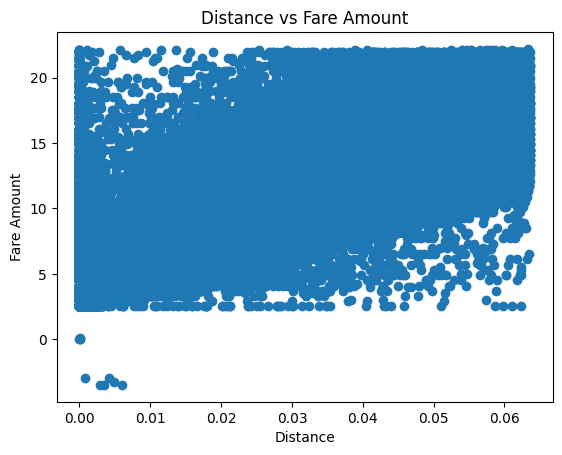

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df["distance"], df["fare_amount"])

plt.xlabel("Distance")
plt.ylabel("Fare Amount")

plt.title("Distance vs Fare Amount")

plt.show()

In [ ]:
# There is a positive relationship between distance and fare amount.
# As distance increases, fare amount also generally increases.